# Sentinel-2 Download Metadata Overview

This notebook analyzes data availability statistics from downloaded Sentinel-2 image stacks.

For each image stack, we calculate:
1. **Missing files**: Proportion of windows where file_exists == false (no image available)
2. **Heavily masked**: Proportion of windows where masked_fraction > 0.5 (>50% cloudy)
3. **Conditional heavily masked**: Among windows where file exists, proportion with masked_fraction > 0.5

In [17]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '../../../'))
from src.utils.utils import get_data_root

In [18]:
# Configuration
data_root = get_data_root()
features_dir = Path(data_root) / 'features'

# Either specify a folder name or use None for the latest
download_folder = None  # e.g., '20260106_112435' or None for latest

if download_folder is None:
    # Find the latest download folder (timestamped directories)
    download_folders = [d for d in features_dir.iterdir() if d.is_dir() and d.name[0].isdigit()]
    if not download_folders:
        raise ValueError(f"No download folders found in {features_dir}")
    download_dir = sorted(download_folders)[-1]
    print(f"Using latest download folder: {download_dir.name}")
else:
    download_dir = features_dir / download_folder
    if not download_dir.exists():
        raise ValueError(f"Download folder not found: {download_dir}")
    print(f"Using specified download folder: {download_dir.name}")

Using latest download folder: 20260106_125441


In [19]:
# Find all metadata JSON files (excluding batch metadata)
metadata_files = [f for f in download_dir.glob('*_metadata.json') 
                  if not f.name.startswith('metadata_') and f.name != 'download_stats.json']

print(f"Found {len(metadata_files)} image stacks to analyze")
print(f"\nExample files:")
for f in list(metadata_files)[:3]:
    print(f"  {f.name}")

Found 10 image stacks to analyze

Example files:
  10_5130509_2016.09.09_metadata.json
  1_5168346_2023.09.06_metadata.json
  4_3581818_2021.09.16_metadata.json


In [20]:
# Analyze each image stack
results = []

for metadata_file in metadata_files:
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    file_id = metadata.get('file_id', metadata_file.stem.replace('_metadata', ''))
    windows = metadata.get('windows', [])
    
    if not windows:
        print(f"Warning: No windows found in {metadata_file.name}")
        continue
    
    total_windows = len(windows)
    
    # Count different categories
    missing_count = 0  # file_exists == false
    heavily_masked_count = 0  # masked_fraction > 0.5
    existing_count = 0  # file_exists == true
    existing_heavily_masked_count = 0  # file_exists == true AND masked_fraction > 0.5
    
    for window in windows:
        file_exists = window.get('file_exists', True)  # Default to True for backwards compatibility
        masked_frac = window.get('masked_fraction', 0.0)
        
        # Category 1: Missing (file doesn't exist)
        if not file_exists:
            missing_count += 1
        else:
            existing_count += 1
        
        # Category 2: Heavily masked (> 0.5)
        if masked_frac > 0.5:
            heavily_masked_count += 1
            
            # Category 3: Among existing files, heavily masked
            if file_exists:
                existing_heavily_masked_count += 1
    
    # Calculate proportions
    prop_missing = missing_count / total_windows
    prop_heavily_masked = heavily_masked_count / total_windows
    
    # Conditional: among existing files, what proportion is heavily masked?
    if existing_count > 0:
        prop_conditional_heavily_masked = existing_heavily_masked_count / existing_count
    else:
        prop_conditional_heavily_masked = np.nan  # All files missing
    
    results.append({
        'file_id': file_id,
        'total_windows': total_windows,
        'missing': prop_missing,
        'heavily_masked': prop_heavily_masked,
        'conditional_heavily_masked': prop_conditional_heavily_masked
    })

df = pd.DataFrame(results)
print(f"\nAnalyzed {len(df)} image stacks")
print(f"\nSummary statistics:")
print(df[['missing', 'heavily_masked', 'conditional_heavily_masked']].describe())


Analyzed 10 image stacks

Summary statistics:
         missing  heavily_masked  conditional_heavily_masked
count  10.000000       10.000000                   10.000000
mean    0.345238        0.469048                    0.139454
std     0.442491        0.349396                    0.109950
min     0.000000        0.119048                    0.000000
25%     0.000000        0.172619                    0.029762
50%     0.011905        0.285714                    0.166667
75%     0.833333        0.845238                    0.192683
max     0.928571        0.928571                    0.309524


In [21]:
# Display first few rows
df.head(10)

,file_id,total_windows,missing,heavily_masked,conditional_heavily_masked
0,10_5130509_2016.09.09,42,0.880952,0.880952,0.000000
1,1_5168346_2023.09.06,42,0.000000,0.261905,0.261905
2,4_3581818_2021.09.16,42,0.000000,0.166667,0.166667
3,9_5130509_2017.07.31,42,0.761905,0.809524,0.200000
4,8_3556386_2017.09.10,42,0.857143,0.857143,0.000000
5,6_5137280_2023.10.12,42,0.000000,0.309524,0.309524
6,5_3581818_2016.06.03,42,0.928571,0.928571,0.000000
7,2_5168346_2019.10.30,42,0.023810,0.190476,0.170732
8,3_3581818_2024.06.30,42,0.000000,0.166667,0.166667
9,7_3556386_2024.08.26,42,0.000000,0.119048,0.119048


/var/folders/1f/_ptk0jz93h39qj25crwwtb0w0000gn/T/ipykernel_6668/3008773009.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='metric', y='proportion', palette='Set2')


Saved boxplot to: /Users/annaboser/Documents/GitHub/smallholder-irrigation-dataset/data/features/20260106_125441/data_availability_boxplot.png


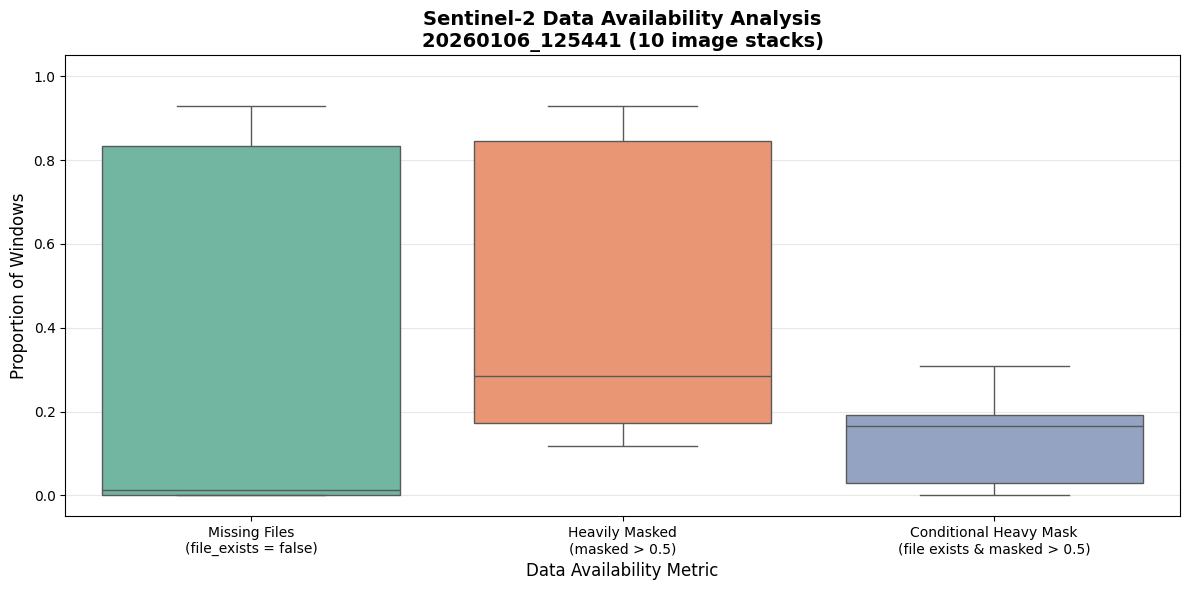


Boxplot shows distribution across 10 image stacks
Each observation represents one image stack with 42 windows


In [22]:
# Prepare data for boxplot
plot_data = pd.melt(
    df,
    id_vars=['file_id', 'total_windows'],
    value_vars=['missing', 'heavily_masked', 'conditional_heavily_masked'],
    var_name='metric',
    value_name='proportion'
)

# Rename metrics for better display
metric_labels = {
    'missing': 'Missing Files\n(file_exists = false)',
    'heavily_masked': 'Heavily Masked\n(masked > 0.5)',
    'conditional_heavily_masked': 'Conditional Heavy Mask\n(file exists & masked > 0.5)'
}
plot_data['metric'] = plot_data['metric'].map(metric_labels)

# Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='metric', y='proportion', palette='Set2')
plt.ylabel('Proportion of Windows', fontsize=12)
plt.xlabel('Data Availability Metric', fontsize=12)
plt.title(f'Sentinel-2 Data Availability Analysis\n{download_dir.name} ({len(df)} image stacks)', 
          fontsize=14, fontweight='bold')
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save figure
output_path = download_dir / 'data_availability_boxplot.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved boxplot to: {output_path}")

plt.show()

print(f"\nBoxplot shows distribution across {len(df)} image stacks")
print(f"Each observation represents one image stack with {df['total_windows'].iloc[0]} windows")

In [23]:
# Additional statistics by metric
print("\nDetailed statistics by metric:")
print("="*70)
for metric in ['missing', 'heavily_masked', 'conditional_heavily_masked']:
    print(f"\n{metric_labels[metric]}:")
    print(f"  Mean: {df[metric].mean():.3f}")
    print(f"  Median: {df[metric].median():.3f}")
    print(f"  Min: {df[metric].min():.3f}")
    print(f"  Max: {df[metric].max():.3f}")
    print(f"  Std: {df[metric].std():.3f}")


Detailed statistics by metric:

Missing Files
(file_exists = false):
  Mean: 0.345
  Median: 0.012
  Min: 0.000
  Max: 0.929
  Std: 0.442

Heavily Masked
(masked > 0.5):
  Mean: 0.469
  Median: 0.286
  Min: 0.119
  Max: 0.929
  Std: 0.349

Conditional Heavy Mask
(file exists & masked > 0.5):
  Mean: 0.139
  Median: 0.167
  Min: 0.000
  Max: 0.310
  Std: 0.110


In [24]:
# Identify problematic image stacks
print("\nImage stacks with highest proportion of missing windows:")
print(df.nlargest(5, 'missing')[['file_id', 'missing', 'heavily_masked']].to_string(index=False))

print("\nImage stacks with highest proportion of heavily masked windows:")
print(df.nlargest(5, 'heavily_masked')[['file_id', 'missing', 'heavily_masked']].to_string(index=False))

print("\nImage stacks with best data availability (lowest missing):")
print(df.nsmallest(5, 'missing')[['file_id', 'missing', 'heavily_masked']].to_string(index=False))


Image stacks with highest proportion of missing windows:
              file_id  missing  heavily_masked
 5_3581818_2016.06.03 0.928571        0.928571
10_5130509_2016.09.09 0.880952        0.880952
 8_3556386_2017.09.10 0.857143        0.857143
 9_5130509_2017.07.31 0.761905        0.809524
 2_5168346_2019.10.30 0.023810        0.190476

Image stacks with highest proportion of heavily masked windows:
              file_id  missing  heavily_masked
 5_3581818_2016.06.03 0.928571        0.928571
10_5130509_2016.09.09 0.880952        0.880952
 8_3556386_2017.09.10 0.857143        0.857143
 9_5130509_2017.07.31 0.761905        0.809524
 6_5137280_2023.10.12 0.000000        0.309524

Image stacks with best data availability (lowest missing):
             file_id  missing  heavily_masked
1_5168346_2023.09.06      0.0        0.261905
4_3581818_2021.09.16      0.0        0.166667
6_5137280_2023.10.12      0.0        0.309524
3_3581818_2024.06.30      0.0        0.166667
7_3556386_2024.08.26   